In [1]:
# CELL 1 - ENVIRONMENT & DEPENDENCIES
# ================================================================

import sys
import subprocess
import importlib.util


def install_if_missing(package, import_name=None):

    import_name = import_name or package

    if importlib.util.find_spec(import_name) is None:

        print(f"[INFO] Installing {package}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])

        print(f"[INFO] {package} installed.")


# ------------------------------------------------
# Core
# ------------------------------------------------

install_if_missing("numpy")
install_if_missing("pandas")
install_if_missing("pillow", "PIL")
install_if_missing("matplotlib")

# ------------------------------------------------
# ML
# ------------------------------------------------

install_if_missing("torch")
install_if_missing("transformers")
install_if_missing("open_clip_torch", "open_clip")

# ------------------------------------------------
# Retrieval
# ------------------------------------------------

install_if_missing("faiss-cpu", "faiss")
# Cài đặt thêm thư viện hỗ trợ load model 4-bit
install_if_missing("bitsandbytes")
install_if_missing("accelerate")
# ------------------------------------------------
# Optional VLM
# ------------------------------------------------

# Qwen2.5-VL will be loaded in Cell 12.
# ------------------------------------------------

print("=" * 70)
print("TRAKE V3 ENVIRONMENT READY")
print("=" * 70)

[INFO] Installing open_clip_torch...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
[INFO] open_clip_torch installed.
[INFO] Installing faiss-cpu...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.6 MB/s eta 0:00:00
[INFO] faiss-cpu installed.
[INFO] Installing bitsandbytes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 49.1 MB/s eta 0:00:00
[INFO] bitsandbytes installed.
TRAKE V3 ENVIRONMENT READY


In [2]:
# CELL 2 - PROJECT CONFIGURATION (V4: SIGLIP-2 & MERGED DATASET)
# ================================================================

from dataclasses import dataclass, field
from pathlib import Path
from typing import List
import logging
import torch

# ================================================================
# LOGGER
# ================================================================
LOGGER = logging.getLogger("TRAKE")
LOGGER.setLevel(logging.INFO)
if not LOGGER.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter("[%(levelname)s] %(message)s")
    handler.setFormatter(formatter)
    LOGGER.addHandler(handler)

# ================================================================
# DATASET & MERGED PATHS
# ================================================================
@dataclass
class DatasetConfig:
    ROOT: Path = Path("/kaggle/input/datasets/bch12222/aic26-keyframes-full-b1")
    MERGED_EMBEDDING_PATH: str = "/kaggle/input/datasets/bch12222/siglip2-embedding/merged_embeddings.npy"
    MERGED_METADATA_PATH: str = "/kaggle/input/datasets/bch12222/siglip2-embedding/merged_metadata.csv"

@dataclass
class OutputConfig:
    ROOT: Path = Path("/kaggle/working")
    CACHE_DIR: Path = Path("/kaggle/working/cache")
    INDEX_DIR: Path = Path("/kaggle/working/index")
    RESULT_DIR: Path = Path("/kaggle/working/results")

# ================================================================
# MODEL 
# ================================================================
@dataclass
class ModelConfig:
    CLIP_MODEL: str = "google/siglip2-so400m-patch16-384" 
    CLIP_PRETRAIN: str = "webli" 

@dataclass
class RetrievalConfig:
    FEATURE_DIM: int = 1152  
    VISUAL_TOP_K: int = 100
    TEXT_TOP_K: int = 50
    TOP_N_VIDEO: int = 20 

@dataclass
class DanteConfig:
    TOP_M_PER_EVENT: int = 20
    MIN_GAP: int = 1
    MAX_GAP: int = 1000
    SIMILARITY_WEIGHT: float = 0.70
    TEMPORAL_WEIGHT: float = 0.30
    TOP_SEQUENCE: int = 10

@dataclass
class FusionConfig:
    VISUAL_WEIGHT: float = 0.60
    TEXT_WEIGHT: float = 0.40
    RRF_K: int = 60

# ================================================================
# SYSTEM
# ================================================================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class SystemConfig:
    DEVICE: str = DEVICE
    RANDOM_SEED: int = SEED
    BATCH_SIZE: int = 64
    NUM_WORKERS: int = 4
    USE_FP16: bool = True

@dataclass
class Config:
    DATASET: DatasetConfig = field(default_factory=DatasetConfig)
    OUTPUT: OutputConfig = field(default_factory=OutputConfig)
    MODEL: ModelConfig = field(default_factory=ModelConfig)
    RETRIEVAL: RetrievalConfig = field(default_factory=RetrievalConfig)
    DANTE: DanteConfig = field(default_factory=DanteConfig)
    FUSION: FusionConfig = field(default_factory=FusionConfig)
    SYSTEM: SystemConfig = field(default_factory=SystemConfig)

CFG = Config()

CFG.OUTPUT.CACHE_DIR.mkdir(parents=True, exist_ok=True)
CFG.OUTPUT.INDEX_DIR.mkdir(parents=True, exist_ok=True)
CFG.OUTPUT.RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("TRAKE V4 CONFIGURATION (SIGLIP-2 READY)")
print("=" * 70)
print("CLIP Model:", CFG.MODEL.CLIP_MODEL)
print("=" * 70)

TRAKE V4 CONFIGURATION (SIGLIP-2 READY)
CLIP Model: google/siglip2-so400m-patch16-384


In [3]:
# CELL 3 - DATASET / DATA MANAGER (IN-MEMORY MERGED DATA WITH AUTO-COLUMN DETECT)
# ================================================================

import os
import pandas as pd
import numpy as np
from pathlib import Path

class DataManager:
    def __init__(self, cfg=CFG):
        self.cfg = cfg
        self.root = Path(cfg.DATASET.ROOT)

        LOGGER.info(f"DataManager V5 initialized. Loading merged data into RAM...")
        
        self.merged_embeddings = np.load(self.cfg.DATASET.MERGED_EMBEDDING_PATH).astype(np.float32)
        self.merged_metadata = pd.read_csv(self.cfg.DATASET.MERGED_METADATA_PATH)
        
        cols = self.merged_metadata.columns.tolist()
        
        # 1. Dò cột Video ID
        self.vid_col = "video_id" if "video_id" in cols else "video" if "video" in cols else cols[0]
        
        # 2. Dò cột Keyframe Path
        if "keyframe_path" in cols:
            self.path_col = "keyframe_path"
        elif "path" in cols:
            self.path_col = "path"
        elif "image_path" in cols:
            self.path_col = "image_path"
        else:
            # Fallback: Lấy cột cuối cùng nếu không tìm thấy từ khóa
            self.path_col = cols[-1] 
            
       # 3. FIX ĐƯỜNG DẪN BỊ LỆCH (Xóa sạch thư mục cũ và thay bằng thư mục mới)
        self.merged_metadata[self.path_col] = self.merged_metadata[self.path_col].str.replace(
            '/kaggle/input/datasets/khoitukieran/aic25-keyframes-full/', 
            '/kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/'
        )
            
        LOGGER.info(f"Auto-detected columns -> Video: '{self.vid_col}', Path: '{self.path_col}'")
        
        # Tạo Lookup Table
        self.video_to_indices = self.merged_metadata.groupby(self.vid_col).groups
        LOGGER.info(f"Loaded {len(self.merged_embeddings)} frames across {len(self.video_to_indices)} videos.")

    # ============================================================
    # LOAD KEYFRAMES BY METADATA 
    # ============================================================
    def load_keyframes(self, video_id):
        if video_id not in self.video_to_indices:
            return []
            
        indices = self.video_to_indices[video_id]
        
        # Lấy thẳng cột đường dẫn dựa trên tên cột đã auto-detect
        paths = self.merged_metadata.loc[indices, self.path_col].tolist()
        
        # Ép kiểu về dạng string chuẩn, sau đó parse sang object Path
        return [Path(str(p)) for p in paths]

    def load_clip_features(self, video_id):
        if video_id not in self.video_to_indices:
            return None
            
        indices = self.video_to_indices[video_id]
        return self.merged_embeddings[indices]

# ================================================================
# INITIALIZE
# ================================================================
dm = DataManager()

# Khởi tạo danh sách Video ID
TEST_VIDEO_IDS = sorted(list(dm.video_to_indices.keys()))

print("=" * 70)
print("DATA MANAGER V5 (MERGED IN-MEMORY)")
print("=" * 70)
print("TEST_VIDEO_IDS:", len(TEST_VIDEO_IDS))
print("=" * 70)

[INFO] DataManager V5 initialized. Loading merged data into RAM...
[INFO] Auto-detected columns -> Video: 'video_id', Path: 'path'
[INFO] Loaded 177321 frames across 873 videos.


DATA MANAGER V5 (MERGED IN-MEMORY)
TEST_VIDEO_IDS: 873


In [4]:
# CELL 4 - QUERY PARSER (Tối ưu cho CLIP)
# ================================================================

from dataclasses import dataclass
from typing import List

@dataclass
class Event:
    event_id: int
    text: str
    original_text: str

class QueryParser:
    def parse(self, query):
        if isinstance(query, str):
            query = [q.strip() for q in query.replace('.', ',').split(',') if q.strip()]

        events = []
        for i, text in enumerate(query):
            original = text.strip()
            expanded_text = f"A clear photo showing: {original.lower()}"
            
            events.append(
                Event(
                    event_id=i,
                    text=expanded_text,
                    original_text=original
                )
            )
        return events

query_parser = QueryParser()
print("=" * 70)
print("Query Parser Ready (with Query Expansion)")
print("=" * 70)

Query Parser Ready (with Query Expansion)


In [5]:
# CELL 5 - MULTIMODAL DATA LOADER (V4 - HUGGING FACE TRANSFORMERS FOR SIGLIP-2)
# ================================================================

import json
import pandas as pd
import numpy as np
import torch
from transformers import AutoProcessor, AutoModel

class MultimodalDataLoader:
    def __init__(self, dm, cfg=CFG):
        self.dm = dm
        self.cfg = cfg
        self.device = torch.device(cfg.SYSTEM.DEVICE)

        LOGGER.info("Loading SigLIP-2 Text Encoder via Hugging Face...")
        
        self.processor = AutoProcessor.from_pretrained(cfg.MODEL.CLIP_MODEL)
        self.model = AutoModel.from_pretrained(cfg.MODEL.CLIP_MODEL).to(self.device)
        self.model.eval()

        LOGGER.info("Multimodal DataLoader initialized.")

    @torch.no_grad()
    def encode_text(self, texts):
        inputs = self.processor(text=texts, padding="max_length", return_tensors="pt").to(self.device)
        
        text_outputs = self.model.get_text_features(**inputs)
        
        if not isinstance(text_outputs, torch.Tensor):
            if hasattr(text_outputs, 'pooler_output') and text_outputs.pooler_output is not None:
                text_features = text_outputs.pooler_output
            elif hasattr(text_outputs, 'text_embeds') and text_outputs.text_embeds is not None:
                text_features = text_outputs.text_embeds
            else:
                text_features = text_outputs[0] # Fallback lấy phần tử đầu tiên
        else:
            text_features = text_outputs
            
        text_features = text_features.float()
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        return text_features.cpu().numpy().astype(np.float32)

    def load_clip_features(self, video_id):
        return self.dm.load_clip_features(video_id)

    def load_transcript(self, video_id):
        candidates = [
            self.cfg.DATASET.ROOT / "transcripts" / f"{video_id}.txt",
            self.cfg.DATASET.ROOT / "transcript" / f"{video_id}.txt",
            self.cfg.DATASET.ROOT / "transcripts" / f"{video_id}.json",
            self.cfg.DATASET.ROOT / "transcript" / f"{video_id}.json",
        ]
        for path in candidates:
            if not path.exists(): continue
            if path.suffix == ".txt": return path.read_text(encoding="utf-8", errors="ignore")
            if path.suffix == ".json":
                with open(path, "r", encoding="utf-8") as f: data = json.load(f)
                if isinstance(data, str): return data
                if isinstance(data, dict): return str(data.get("text", data.get("transcript", "")))
        return ""

    def load_summary(self, video_id):
        candidates = [
            self.cfg.DATASET.ROOT / "summaries" / f"{video_id}.txt",
            self.cfg.DATASET.ROOT / "summary" / f"{video_id}.txt",
            self.cfg.DATASET.ROOT / "summaries" / f"{video_id}.json",
            self.cfg.DATASET.ROOT / "summary" / f"{video_id}.json",
        ]
        for path in candidates:
            if not path.exists(): continue
            if path.suffix == ".txt": return path.read_text(encoding="utf-8", errors="ignore")
            if path.suffix == ".json":
                with open(path, "r", encoding="utf-8") as f: data = json.load(f)
                if isinstance(data, str): return data
                if isinstance(data, dict): return str(data.get("summary", data.get("text", "")))
        return ""

    def load_video(self, video_id):
        return {
            "video_id": video_id,
            "keyframes": self.dm.load_keyframes(video_id),
            "clip_features": self.load_clip_features(video_id),
            "transcript": self.load_transcript(video_id),
            "summary": self.load_summary(video_id)
        }

# ================================================================
# INITIALIZE
# ================================================================
multimodal_loader = MultimodalDataLoader(dm)

print("=" * 70)
print("MULTIMODAL DATA LOADER V4 READY (SIGLIP-2 HUGGINGFACE)")
print("=" * 70)

[INFO] Loading SigLIP-2 Text Encoder via Hugging Face...


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

[INFO] Multimodal DataLoader initialized.


MULTIMODAL DATA LOADER V4 READY (SIGLIP-2 HUGGINGFACE)


In [6]:
# CELL 6 - VISUAL RETRIEVAL INDEX (ONE-SHOT FAISS LOAD)
# ================================================================

import faiss
import numpy as np
from dataclasses import dataclass

@dataclass
class VisualRetrievalResult:
    video_id: str
    frame_idx: int
    similarity: float
    keyframe_path: str
    event_id: int

class VisualRetrievalIndex:
    def __init__(self, loader, cfg=CFG):
        self.loader = loader
        self.cfg = cfg
        
        self.dim = self.loader.dm.merged_embeddings.shape[1]
        self.index = faiss.IndexFlatIP(self.dim)
        self.records = []

    def build(self):
        print("=" * 70)
        print("BUILDING VISUAL FAISS INDEX (MERGED BATCH)")
        print("=" * 70)

        embeddings = self.loader.dm.merged_embeddings.copy() 
        df_meta = self.loader.dm.merged_metadata

        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / (norms + 1e-12)

        self.index.add(embeddings)

        self.records = df_meta.to_dict('records')

        print(f"[OK] FAISS loaded {self.index.ntotal} vector embeddings.")
        print("=" * 70)

    def search(self, query_embedding, event_id, top_k=100):
        if self.index.ntotal == 0:
            return []

        query_embedding = np.asarray(query_embedding, dtype=np.float32).reshape(1, -1)
        query_embedding /= (np.linalg.norm(query_embedding, axis=1, keepdims=True) + 1e-12)
        k = min(top_k, self.index.ntotal)

        scores, indices = self.index.search(query_embedding, k)
        results = []

        for score, idx in zip(scores[0], indices[0]):
            if idx < 0: continue
            
            record = self.records[idx]
            
            vid = record.get("video_id", record.get("video", "UNKNOWN"))
            f_idx = record.get("frame_idx", record.get("frame", record.get("frame_id", 0)))
            k_path = record.get("keyframe_path", record.get("path", record.get("image_path", "")))

            results.append(
                VisualRetrievalResult(
                    video_id=vid,
                    frame_idx=int(f_idx),
                    similarity=float(score),
                    keyframe_path=str(k_path),
                    event_id=event_id
                )
            )
        return results

# ================================================================
# INITIALIZE & BUILD
# ================================================================
visual_index = VisualRetrievalIndex(multimodal_loader)
visual_index.build()

print("=" * 70)
print(f"VISUAL RETRIEVAL INDEX V4 READY (DIM: {visual_index.dim})")
print("=" * 70)

BUILDING VISUAL FAISS INDEX (MERGED BATCH)
[OK] FAISS loaded 177321 vector embeddings.
VISUAL RETRIEVAL INDEX V4 READY (DIM: 1152)


In [7]:
# CELL 7 - TEXT / TRANSCRIPT RETRIEVAL INDEX
# ================================================================

import faiss
from dataclasses import dataclass


@dataclass
class TextRetrievalResult:

    video_id: str

    text_type: str

    text: str

    similarity: float


class TextRetrievalIndex:

    def __init__(
        self,
        loader,
        cfg=CFG
    ):

        self.loader = loader

        self.cfg = cfg

        self.records = []

        self.embeddings = None

        self.index = None


    def build(
        self,
        video_ids
    ):

        records = []

        for video_id in video_ids:

            transcript = self.loader.load_transcript(
                video_id
            )

            summary = self.loader.load_summary(
                video_id
            )

            if transcript:

                records.append({
                    "video_id": video_id,
                    "text_type": "transcript",
                    "text": transcript
                })

            if summary:

                records.append({
                    "video_id": video_id,
                    "text_type": "summary",
                    "text": summary
                })

        self.records = records

        if not records:

            LOGGER.warning(
                "No transcript/summary data found."
            )

            return

        texts = [
            r["text"]
            for r in records
        ]

        self.embeddings = \
            self.loader.encode_text(
                texts
            )

        self.index = faiss.IndexFlatIP(
            self.embeddings.shape[1]
        )

        self.index.add(
            self.embeddings
        )

        LOGGER.info(
            f"Text index built: "
            f"{len(records)} records"
        )


    def search(
        self,
        query,
        top_k=50
    ):

        if self.index is None:

            return []

        embedding = self.loader.encode_text(
            [query]
        )

        scores, indices = self.index.search(
            embedding,
            min(
                top_k,
                len(self.records)
            )
        )

        results = []

        for score, idx in zip(
            scores[0],
            indices[0]
        ):

            if idx < 0:
                continue

            record = self.records[idx]

            results.append(
                TextRetrievalResult(
                    video_id=record["video_id"],
                    text_type=record["text_type"],
                    text=record["text"],
                    similarity=float(score)
                )
            )

        return results


text_index = TextRetrievalIndex(
    multimodal_loader
)

text_index.build(
    TEST_VIDEO_IDS
)

print("=" * 70)
print("Text Retrieval Index Ready")
print("=" * 70)

[WARNING] No transcript/summary data found.


Text Retrieval Index Ready


In [8]:
# CELL 8 - MULTIMODAL CANDIDATE RETRIEVAL
# ================================================================

from collections import defaultdict
from dataclasses import dataclass


@dataclass
class MultimodalCandidate:

    video_id: str

    event_id: int

    visual_score: float

    text_score: float

    combined_score: float

    visual_frames: list


class MultimodalCandidateRetriever:

    def __init__(
        self,
        loader,
        visual_index,
        text_index,
        cfg=CFG
    ):

        self.loader = loader
        self.visual_index = visual_index
        self.text_index = text_index
        self.cfg = cfg


    def retrieve_event(
        self,
        event
    ):

        embedding = self.loader.encode_text(
            [event.text]
        )[0]

        visual = self.visual_index.search(
            embedding,
            event.event_id,
            self.cfg.RETRIEVAL.VISUAL_TOP_K
        )

        text = self.text_index.search(
            event.text,
            self.cfg.RETRIEVAL.TEXT_TOP_K
        )

        visual_by_video = defaultdict(list)

        for r in visual:

            visual_by_video[
                r.video_id
            ].append(r)

        text_by_video = {

            r.video_id:
                r.similarity

            for r in text
        }

        candidates = []

        for video_id, frames in visual_by_video.items():

            visual_score = max(
                r.similarity
                for r in frames
            )

            text_score = text_by_video.get(
                video_id,
                0.0
            )

            combined = (
                self.cfg.FUSION.VISUAL_WEIGHT
                * visual_score
                +
                self.cfg.FUSION.TEXT_WEIGHT
                * text_score
            )

            candidates.append(
                MultimodalCandidate(
                    video_id=video_id,
                    event_id=event.event_id,
                    visual_score=visual_score,
                    text_score=text_score,
                    combined_score=combined,
                    visual_frames=frames
                )
            )

        return sorted(
            candidates,
            key=lambda x: x.combined_score,
            reverse=True
        )


multimodal_retriever = MultimodalCandidateRetriever(
    multimodal_loader,
    visual_index,
    text_index
)

print(
    "Multimodal Candidate Retrieval Ready"
)

Multimodal Candidate Retrieval Ready


In [9]:
# CELL 9 - CANDIDATE FUSION + EXPANSION
# ================================================================

from collections import defaultdict

class CandidateFusion:
    def __init__(
        self,
        retriever,
        cfg=CFG
    ):

        self.retriever = retriever
        self.cfg = cfg

    def retrieve(
        self,
        events
    ):

        by_video = defaultdict(
            lambda: defaultdict(list)
        )

        for event in events:

            candidates = \
                self.retriever.retrieve_event(
                    event
                )

            for candidate in candidates:

                by_video[
                    candidate.video_id
                ][
                    candidate.event_id
                ].append(
                    candidate
                )

        fused = []

        for video_id, event_dict in by_video.items():

            event_scores = {}

            for event_id, candidates in event_dict.items():

                event_scores[event_id] = max(
                    c.combined_score
                    for c in candidates
                )

            coverage = (
                len(event_scores)
                /
                len(events)
            )

            score = (
                sum(event_scores.values())
                /
                max(len(event_scores), 1)
            )

            score *= (
                0.7 +
                0.3 * coverage
            )

            fused.append({

                "video_id": video_id,

                "score": score,

                "coverage": coverage,

                "events": event_dict
            })

        fused.sort(
            key=lambda x: x["score"],
            reverse=True
        )

        return fused[
            :self.cfg.RETRIEVAL.TOP_N_VIDEO
        ]
candidate_fusion = CandidateFusion(multimodal_retriever)
print("=" * 70)
print("CANDIDATE FUSION READY")
print("=" * 70)

CANDIDATE FUSION READY


In [10]:
# CELL 10 - DANTE TEMPORAL DP
# Project : TRAKE V3
#
# DANTE TEMPORAL ALIGNMENT
# ---------------------------------------------------------------
# This cell replaces the previously inferred DANTE implementation.
#
# Based directly on the original DANTE code supplied by the user.
#
# Pipeline:
#
#   Event-wise visual candidates
#            ↓
#       Temporal DP
#            ↓
#       Backtracking
#            ↓
#   1 temporal path / video
#
# For N query events:
#
#       Event 0 → Frame 0
#       Event 1 → Frame 1
#       ...
#       Event N → Frame N
#
# The output is ONE temporal sequence, not Top-K independent frames.
#
# IMPORTANT:
# - FAISS is used as the retrieval backend in TRAKE V3.
# - DANTE DP logic is preserved.
# - No Qwen verification here.
# - No final ranking here.
# - No candidate expansion here.
# ================================================================

import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

DANTE_TOP_K_PER_EVENT = 100
DANTE_MIN_FRAME_GAP = 2
DANTE_IDEAL_GAP = 15 #25 10        # Chỉnh tùy thuộc vào khoảng cách (tính bằng frame/giây) giữa các event trong video
DANTE_LAMBDA_WEIGHT = 0.0002 #0.002 0.5 Tăng trọng số phạt để ép các frame phải tuân thủ trình tự thời gian sát nhau

@dataclass
class DanteCandidate:

    frame_idx: int
    score: float
    keyframe_path: str


class DANTETemporalDP:

    """
    Original DANTE-style temporal dynamic programming.

    Given:
        candidates[event_i]

    Find:
        one frame for every event

    subject to:

        frame_i >= frame_(i-1) + min_frame_gap

    Objective:

        path_score =
            previous_score
            + current_similarity
            - gap_penalty
    """
    def optimize(
        self,
        video_id,
        event_candidates
    ):
    
        converted_candidates = []
    
        for event_results in event_candidates:
    
            # Already converted
            if (
                event_results
                and isinstance(
                    event_results[0],
                    DanteCandidate
                )
            ):
                converted_candidates.append(
                    event_results
                )
                continue
    
            event_converted = []
    
            for result in event_results:
    
                # ----------------------------------------------------
                # VisualRetrievalResult
                # ----------------------------------------------------
    
                frame_idx = getattr(
                    result,
                    "frame_idx",
                    None
                )
    
                if frame_idx is None:
                    frame_idx = getattr(
                        result,
                        "frame",
                        None
                    )
    
                # ----------------------------------------------------
                # Similarity score
                # ----------------------------------------------------
    
                score = getattr(
                    result,
                    "similarity",
                    None
                )
    
                if score is None:
                    score = getattr(
                        result,
                        "score",
                        None
                    )
    
                if score is None:
                    score = getattr(
                        result,
                        "retrieval_score",
                        None
                    )
    
                # ----------------------------------------------------
                # Keyframe path
                # ----------------------------------------------------
    
                keyframe_path = getattr(
                    result,
                    "keyframe_path",
                    ""
                )
    
                # ----------------------------------------------------
                # Dictionary fallback
                # ----------------------------------------------------
    
                if isinstance(result, dict):
    
                    frame_idx = result.get(
                        "frame_idx",
                        result.get("frame")
                    )
    
                    score = result.get(
                        "similarity",
                        result.get(
                            "score",
                            result.get(
                                "retrieval_score",
                                0.0
                            )
                        )
                    )
    
                    keyframe_path = result.get(
                        "keyframe_path",
                        ""
                    )
    
                # ----------------------------------------------------
                # Invalid candidate
                # ----------------------------------------------------
    
                if frame_idx is None:
                    continue
    
                if score is None:
                    score = 0.0
    
                event_converted.append(
    
                    DanteCandidate(
    
                        frame_idx=int(
                            frame_idx
                        ),
    
                        score=float(
                            score
                        ),
    
                        keyframe_path=str(
                            keyframe_path
                        )
    
                    )
    
                )
    
            event_converted.sort(
                key=lambda x: x.frame_idx
            )
    
            converted_candidates.append(
                event_converted
            )
    
        # ------------------------------------------------------------
        # Run actual DANTE DP
        # ------------------------------------------------------------
    
        return self.search(
            event_candidates=converted_candidates,
            video_id=video_id
        )
    def __init__(
        self,

        top_k_per_event: int = DANTE_TOP_K_PER_EVENT,

        min_frame_gap: int = DANTE_MIN_FRAME_GAP,

        ideal_gap: int = DANTE_IDEAL_GAP,

        lambda_weight: float = DANTE_LAMBDA_WEIGHT,
    ):

        self.top_k_per_event = top_k_per_event

        self.min_frame_gap = min_frame_gap

        self.ideal_gap = ideal_gap

        self.lambda_weight = lambda_weight

        LOGGER.info(
            "DANTE Temporal DP initialized."
        )


    # ============================================================
    # GAP PENALTY
    # ============================================================

    def gap_penalty(
        self,
        current_frame: int,
        previous_frame: int,
    ) -> float:

        return (
            self.lambda_weight
            * abs(
                (current_frame - previous_frame)
                - self.ideal_gap
            )
        )


    # ============================================================
    # TEMPORAL DP
    # ============================================================

    def search(
        self,
        event_candidates: List[List[DanteCandidate]],
        video_id: str,
    ) -> Optional[Dict]:

        # --------------------------------------------------------
        # Basic validation
        # --------------------------------------------------------

        if not event_candidates:

            LOGGER.warning(
                f"DANTE: no candidates for {video_id}"
            )

            return None


        n_events = len(
            event_candidates
        )


        # --------------------------------------------------------
        # Every event must have at least one candidate
        # --------------------------------------------------------

        for i, candidates in enumerate(
            event_candidates
        ):

            if not candidates:

                LOGGER.warning(
                    f"DANTE: Event {i} has no candidates "
                    f"for video {video_id}"
                )

                return None


        # ========================================================
        # DP TABLE
        # ========================================================

        dp = [

            [
                -1e9
                for _ in candidates
            ]

            for candidates in event_candidates

        ]


        # ========================================================
        # TRACE TABLE
        # ========================================================

        trace = [

            [
                -1
                for _ in candidates
            ]

            for candidates in event_candidates

        ]


        # ========================================================
        # INITIAL EVENT
        # ========================================================

        for j, candidate in enumerate(
            event_candidates[0]
        ):

            dp[0][j] = candidate.score


        # ========================================================
        # DP TRANSITION
        # ========================================================

        for i in range(
            1,
            n_events
        ):

            current_candidates = (
                event_candidates[i]
            )

            previous_candidates = (
                event_candidates[i - 1]
            )


            for j, current in enumerate(
                current_candidates
            ):

                best_score = -1e9

                best_k = -1


                # ------------------------------------------------
                # Check every candidate from previous event
                # ------------------------------------------------

                for k, previous in enumerate(
                    previous_candidates
                ):

                    previous_frame = (
                        previous.frame_idx
                    )

                    current_frame = (
                        current.frame_idx
                    )


                    # ------------------------------------------------
                    # TEMPORAL CONSTRAINT
                    # ------------------------------------------------

                    if (
                        previous_frame
                        + self.min_frame_gap
                        > current_frame
                    ):

                        continue


                    # ------------------------------------------------
                    # GAP PENALTY
                    # ------------------------------------------------

                    penalty = self.gap_penalty(

                        current_frame=current_frame,

                        previous_frame=previous_frame,

                    )


                    # ------------------------------------------------
                    # DANTE PATH SCORE
                    # ------------------------------------------------

                    score_path = (

                        dp[i - 1][k]

                        + current.score

                        - penalty

                    )


                    # ------------------------------------------------
                    # KEEP BEST PREVIOUS STATE
                    # ------------------------------------------------

                    if (
                        score_path
                        > best_score
                    ):

                        best_score = (
                            score_path
                        )

                        best_k = k


                # ------------------------------------------------
                # Store transition
                # ------------------------------------------------

                if best_k != -1:

                    dp[i][j] = (
                        best_score
                    )

                    trace[i][j] = (
                        best_k
                    )


        # ========================================================
        # CHECK FINAL STATE
        # ========================================================

        final_scores = dp[-1]


        if not final_scores:

            return None


        # --------------------------------------------------------
        # Best final candidate
        # --------------------------------------------------------

        last_j = int(
            np.argmax(
                final_scores
            )
        )


        best_score = (
            final_scores[last_j]
        )


        # --------------------------------------------------------
        # No valid temporal path
        # --------------------------------------------------------

        if best_score <= -1e8:

            LOGGER.warning(
                f"DANTE: no valid temporal path "
                f"for {video_id}"
            )

            return None


        # ========================================================
        # BACKTRACKING
        # ========================================================

        path = []

        current_j = last_j


        for i in range(
            n_events - 1,
            -1,
            -1
        ):

            if current_j == -1:

                return None


            candidate = (
                event_candidates[i][current_j]
            )


            path.append(
                candidate
            )


            current_j = (
                trace[i][current_j]
            )


        # Reverse path

        path.reverse()


        # ========================================================
        # BUILD RESULT
        # ========================================================

        frame_sequence = [

            candidate.frame_idx

            for candidate in path

        ]


        # --------------------------------------------------------
        # Keyframe paths
        # --------------------------------------------------------

        keyframe_paths = [

            candidate.keyframe_path

            for candidate in path

        ]


        # --------------------------------------------------------
        # Event → frame mapping
        # --------------------------------------------------------

        event_frames = [

            {
                "event_idx": i,

                "frame_idx": candidate.frame_idx,

                "score": float(
                    candidate.score
                ),

                "keyframe_path":
                    candidate.keyframe_path,

            }

            for i, candidate in enumerate(
                path
            )

        ]


        return {

            "video_id": video_id,

            "frame_sequence":
                frame_sequence,

            "keyframe_paths":
                keyframe_paths,

            "event_frames":
                event_frames,

            "score":
                float(best_score),

        }


# ================================================================
# FAISS → DANTE CANDIDATE CONVERSION
# ================================================================

def build_dante_candidates(
    retrieval_results: List,
    top_k: int = DANTE_TOP_K_PER_EVENT,
) -> List[DanteCandidate]:

    """
    Convert Cell 8/9 retrieval output into the format
    required by DANTE.

    Expected retrieval result fields:

        frame_idx
        similarity
        keyframe_path

    The function is deliberately tolerant of dictionaries
    produced by different V3 retrieval stages.
    """

    candidates = []


    for result in retrieval_results[:top_k]:

        # --------------------------------------------------------
        # Frame index
        # --------------------------------------------------------

        if isinstance(
            result,
            dict
        ):

            frame_idx = result.get(
                "frame_idx"
            )

            if frame_idx is None:

                frame_idx = result.get(
                    "frame"
                )


            # ----------------------------------------------------
            # Similarity score
            # ----------------------------------------------------

            score = result.get(
                "similarity"
            )

            if score is None:

                score = result.get(
                    "score"
                )

            if score is None:

                score = result.get(
                    "retrieval_score",
                    0.0
                )


            # ----------------------------------------------------
            # Keyframe path
            # ----------------------------------------------------

            keyframe_path = result.get(
                "keyframe_path",
                ""
            )


        else:

            raise TypeError(
                "Retrieval result must be a dict."
            )


        if frame_idx is None:

            continue


        candidates.append(

            DanteCandidate(

                frame_idx=int(
                    frame_idx
                ),

                score=float(
                    score
                ),

                keyframe_path=str(
                    keyframe_path
                ),

            )

        )


    # ------------------------------------------------------------
    # DANTE sorts candidates temporally
    # ------------------------------------------------------------

    candidates.sort(
        key=lambda x: x.frame_idx
    )


    return candidates


# ================================================================
# INITIALIZE DANTE
# ================================================================

dante_temporal_dp = DANTETemporalDP(

    top_k_per_event=
        DANTE_TOP_K_PER_EVENT,

    min_frame_gap=
        DANTE_MIN_FRAME_GAP,

    ideal_gap=
        DANTE_IDEAL_GAP,

    lambda_weight=
        DANTE_LAMBDA_WEIGHT,

)

print("=" * 70)
print("DANTE TEMPORAL DP")
print("=" * 70)

print(
    f"Top-K / event    : "
    f"{DANTE_TOP_K_PER_EVENT}"
)

print(
    f"Minimum gap      : "
    f"{DANTE_MIN_FRAME_GAP}"
)

print(
    f"Ideal gap        : "
    f"{DANTE_IDEAL_GAP}"
)

print(
    f"Lambda weight    : "
    f"{DANTE_LAMBDA_WEIGHT}"
)

print("=" * 70)
print("DANTE Temporal DP Ready")
print("=" * 70)

[INFO] DANTE Temporal DP initialized.


DANTE TEMPORAL DP
Top-K / event    : 100
Minimum gap      : 2
Ideal gap        : 15
Lambda weight    : 0.0002
DANTE Temporal DP Ready


In [11]:
# CELL 11 - CANDIDATE FRAME GENERATOR


from dataclasses import dataclass
from typing import List


# ================================================================
# CANDIDATE FRAME
# ================================================================

@dataclass
class CandidateFrame:

    video_id: str

    event_id: int

    frame_idx: int

    keyframe_path: str

    # Original visual retrieval similarity
    similarity: float = 0.0

    # Explicit retrieval score
    retrieval_score: float = 0.0

    # DANTE temporal score
    dante_score: float = 0.0


# ================================================================
# CANDIDATE FRAME GENERATOR
# ================================================================

class CandidateFrameGenerator:

    def __init__(self, data_manager=None):

        self.data_manager = data_manager

        LOGGER.info(
            "Candidate Frame Generator initialized."
        )


    # ============================================================
    # GENERATE
    # ============================================================

    def generate(
        self,
        sequence,
        candidate_video
    ) -> List[CandidateFrame]:

        """
        Convert DANTE temporal sequence into candidate frames.

        Parameters
        ----------
        sequence:
            Dictionary returned by DANTETemporalDP.search()

        candidate_video:
            Video ID.

        Returns
        -------
        List[CandidateFrame]
        """

        # --------------------------------------------------------
        # Validate DANTE output
        # --------------------------------------------------------

        if sequence is None:

            return []


        if not isinstance(
            sequence,
            dict
        ):

            raise TypeError(
                "DANTE sequence must be a dict."
            )


        # --------------------------------------------------------
        # Video ID
        # --------------------------------------------------------

        video_id = sequence.get(
            "video_id",
            candidate_video
        )


        # ========================================================
        # PREFERRED SOURCE:
        # event_frames
        # ========================================================

        event_frames = sequence.get(
            "event_frames",
            []
        )


        candidates = []


        # ========================================================
        # CASE 1:
        # DANTE provides event_frames
        # ========================================================

        if event_frames:

            for event in event_frames:

                event_id = int(
                    event.get(
                        "event_idx",
                        0
                    )
                )

                frame_idx = int(
                    event.get(
                        "frame_idx"
                    )
                )

                score = float(
                    event.get(
                        "score",
                        0.0
                    )
                )

                keyframe_path = str(
                    event.get(
                        "keyframe_path",
                        ""
                    )
                )


                # ------------------------------------------------
                # Recover keyframe path if necessary
                # ------------------------------------------------

                if (
                    not keyframe_path
                    and self.data_manager is not None
                ):

                    try:

                        keyframe_path = (
                            self.data_manager
                            .get_keyframe_path(
                                video_id,
                                frame_idx
                            )
                        )

                    except Exception:

                        keyframe_path = ""


                candidates.append(
                
                    CandidateFrame(
                
                        video_id=video_id,
                
                        event_id=event_id,
                
                        frame_idx=frame_idx,
                
                        keyframe_path=keyframe_path,
                
                        similarity=score,
                
                        retrieval_score=score,
                
                        dante_score=score,
                
                    )
                
                )


        # ========================================================
        # CASE 2:
        # fallback to frame_sequence
        # ========================================================

        else:

            frame_sequence = sequence.get(
                "frame_sequence",
                []
            )

            keyframe_paths = sequence.get(
                "keyframe_paths",
                []
            )

            dante_score = float(
                sequence.get(
                    "score",
                    0.0
                )
            )


            for event_id, frame_idx in enumerate(
                frame_sequence
            ):

                keyframe_path = ""

                if (
                    event_id
                    < len(keyframe_paths)
                ):

                    keyframe_path = str(
                        keyframe_paths[event_id]
                    )


                # ------------------------------------------------
                # Recover keyframe path if necessary
                # ------------------------------------------------

                if (
                    not keyframe_path
                    and self.data_manager is not None
                ):

                    try:

                        keyframe_path = (
                            self.data_manager
                            .get_keyframe_path(
                                video_id,
                                int(frame_idx)
                            )
                        )

                    except Exception:

                        keyframe_path = ""


                candidates.append(

                    CandidateFrame(
                
                        video_id=video_id,
                
                        event_id=event_id,
                
                        frame_idx=int(frame_idx),
                
                        keyframe_path=keyframe_path,
                
                        similarity=dante_score,
                
                        retrieval_score=dante_score,
                
                        dante_score=dante_score,
                
                    )
                
                )


        # ========================================================
        # DEBUG
        # ========================================================

        print("=" * 70)
        print("DANTE → CANDIDATE FRAME GENERATOR")
        print("=" * 70)

        print(
            f"Video       : {video_id}"
        )

        print(
            f"Candidates  : {len(candidates)}"
        )


        for candidate in candidates:

            print(
                f"Event={candidate.event_id} | "
                f"Frame={candidate.frame_idx} | "
                f"DANTE={candidate.dante_score:.6f} | "
                f"{candidate.keyframe_path}"
            )


        print("=" * 70)


        return candidates


# ================================================================
# INITIALIZE
# ================================================================

candidate_frame_generator = CandidateFrameGenerator(
    data_manager=dm
)


print(
    "Candidate Frame Generator Ready"
)

[INFO] Candidate Frame Generator initialized.


Candidate Frame Generator Ready


In [12]:
# CELL 12 - TRAKE V4
# ================================================================

from dataclasses import dataclass
import numpy as np

@dataclass
class DanteCandidate:
    frame_idx: int
    score: float
    keyframe_path: str

class TRAKE:
    def __init__(self, query_parser, candidate_fusion, dante, frame_generator, loader, cfg=CFG):
        self.query_parser = query_parser
        self.candidate_fusion = candidate_fusion
        self.dante = dante
        self.frame_generator = frame_generator
        self.loader = loader
        self.cfg = cfg

    def _local_search_candidates(self, video_id, events):
        video_features = self.loader.load_clip_features(video_id)
        if video_features is None: return []

        norms = np.linalg.norm(video_features, axis=1, keepdims=True)
        video_features = video_features / (norms + 1e-12)
        
        keyframes = self.loader.dm.load_keyframes(video_id)
        event_candidates = []

        for event in events:
            original_text = getattr(event, "original_text", event.text)
            query_emb = self.loader.encode_text([original_text])[0]
            query_emb = query_emb / (np.linalg.norm(query_emb) + 1e-12)
            sims = np.dot(video_features, query_emb)
            
            k = min(self.cfg.RETRIEVAL.VISUAL_TOP_K, len(sims))
            top_indices = np.argsort(sims)[::-1][:k]

            candidates = []
            for idx in top_indices:
                if idx < len(keyframes):
                    candidates.append(DanteCandidate(int(keyframes[idx].stem), float(sims[idx]), str(keyframes[idx])))

            candidates.sort(key=lambda x: x.frame_idx)
            event_candidates.append(candidates)
            
        return event_candidates

    def _run_dante(self, video_id, event_candidates):
        if any(len(candidates) == 0 for candidates in event_candidates): return None
        return self.dante.optimize(video_id, event_candidates)

    def search(self, query):
        events = self.query_parser.parse(query)
        if not events: return {"results": []}

        fusion_output = self.candidate_fusion.retrieve(events)
        if not fusion_output: return {"results": []}

        dante_passed_videos = []
        for video_result in fusion_output:
            video_id = video_result.get("video_id") if isinstance(video_result, dict) else getattr(video_result, "video_id", None)
            if not video_id: continue

            event_candidates = self._local_search_candidates(video_id, events)
            if not event_candidates: continue
            
            sequence = self._run_dante(video_id, event_candidates)
            if sequence is None: continue
            
            dante_passed_videos.append({
                "video_id": video_id,
                "sequence": sequence,
                "dante_score": sequence.get("score", 0.0)
            })

        dante_passed_videos.sort(key=lambda x: x["dante_score"], reverse=True)
        top_videos = dante_passed_videos[:5]  

        final_results = []

        for video_data in top_videos:
            video_id = video_data["video_id"]
            sequence = video_data["sequence"]
            
            candidates_for_display = self.frame_generator.generate(sequence, video_id)
            
            ranked_frames = []
            for cand in candidates_for_display:
                visual_score = getattr(cand, "dante_score", getattr(cand, "similarity", 0.0))
                ranked_frames.append({
                    "video_id": video_id, 
                    "frame_idx": cand.frame_idx, 
                    "event_id": cand.event_id,
                    "keyframe_path": cand.keyframe_path, 
                    "visual_score": float(visual_score),
                    "semantic_score": 1.0, 
                    "verified": True,      
                    "final_score": float(visual_score)
                })

            final_results.append({
                "video_id": video_id,
                "score": video_data["dante_score"],
                "events": ranked_frames
            })

        return {"results": final_results}

trake = TRAKE(
    query_parser=query_parser, 
    candidate_fusion=candidate_fusion, 
    dante=dante_temporal_dp, 
    frame_generator=candidate_frame_generator, 
    loader=multimodal_loader, 
    cfg=CFG
)

print("=" * 70)
print("TRAKE V3 READY")
print("=" * 70)

TRAKE V3 READY


ĐANG TÌM KIẾM CHO QUERY:
   Event 0: An upclose of the first seafood
   Event 1: An upclose of the second seafood
   Event 2: colorful ingredients
DANTE → CANDIDATE FRAME GENERATOR
Video       : L26_V395
Candidates  : 3
Event=0 | Frame=135 | DANTE=0.167785 | /kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/Keyframes_L26_d/keyframes/L26_V395/135.jpg
Event=1 | Frame=147 | DANTE=0.177579 | /kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/Keyframes_L26_d/keyframes/L26_V395/147.jpg
Event=2 | Frame=156 | DANTE=0.086397 | /kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/Keyframes_L26_d/keyframes/L26_V395/156.jpg
DANTE → CANDIDATE FRAME GENERATOR
Video       : L26_V338
Candidates  : 3
Event=0 | Frame=155 | DANTE=0.177624 | /kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/Keyframes_L26_d/keyframes/L26_V338/155.jpg
Event=1 | Frame=158 | DANTE=0.169468 | /kaggle/input/datasets/bch12222/aic26-keyframes-full-b1/Keyframes_L26_d/keyframes/L26_V338/158.jpg
Event=2 | Frame=1

/tmp/ipykernel_58/864018157.py:108: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


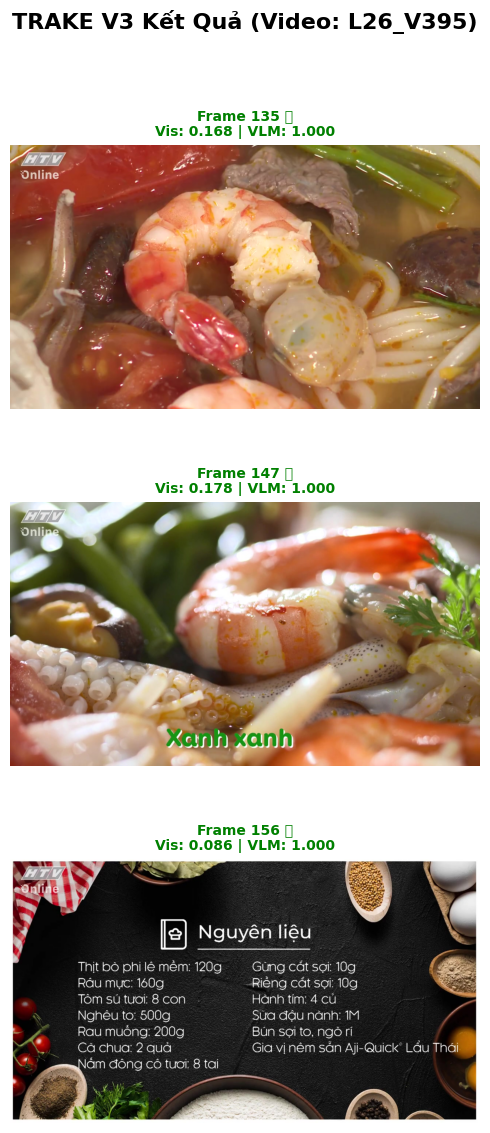


VIDEO RANK 2: L26_V338 | Final Score: 0.4227


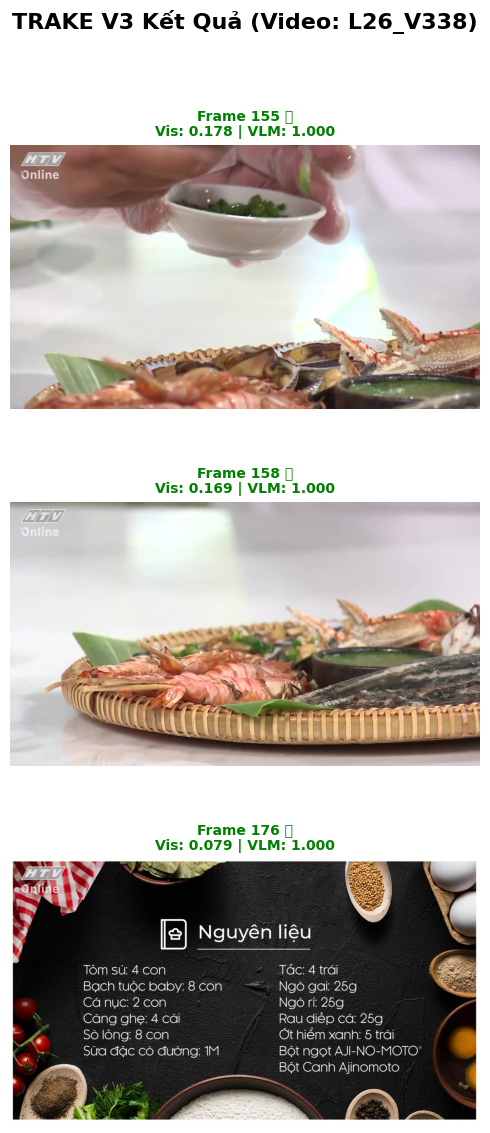


VIDEO RANK 3: L26_V227 | Final Score: 0.4175


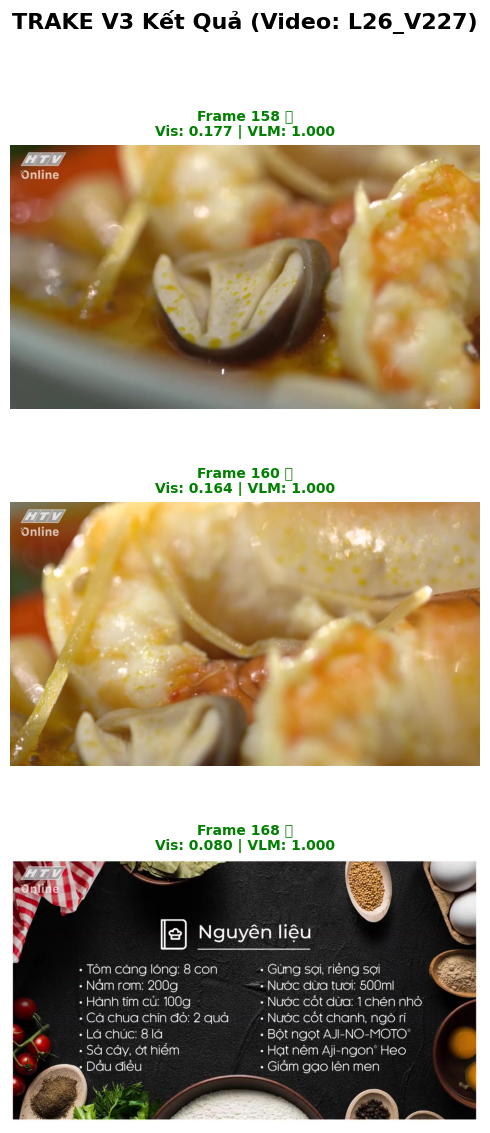


VIDEO RANK 4: L26_V396 | Final Score: 0.4171


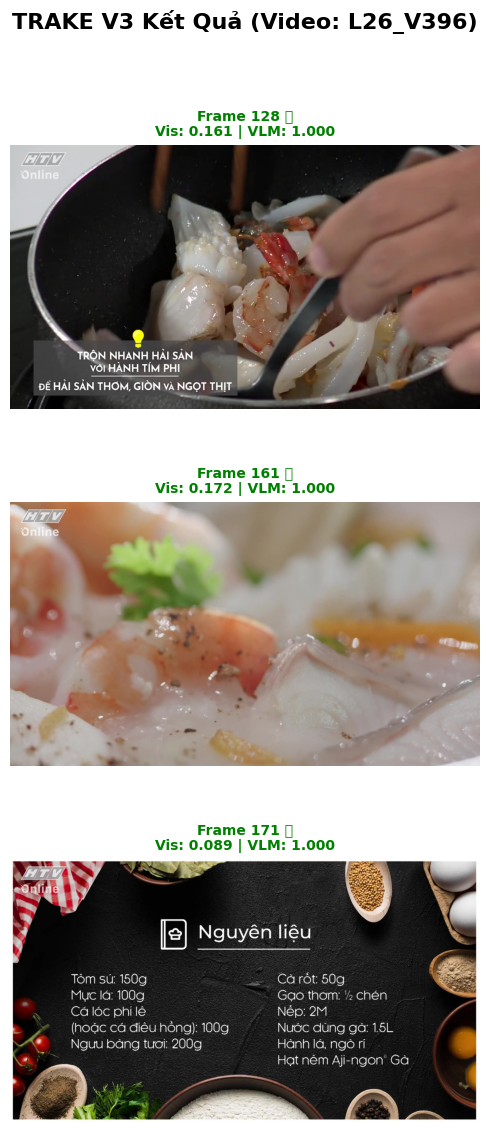


VIDEO RANK 5: L26_V359 | Final Score: 0.4102


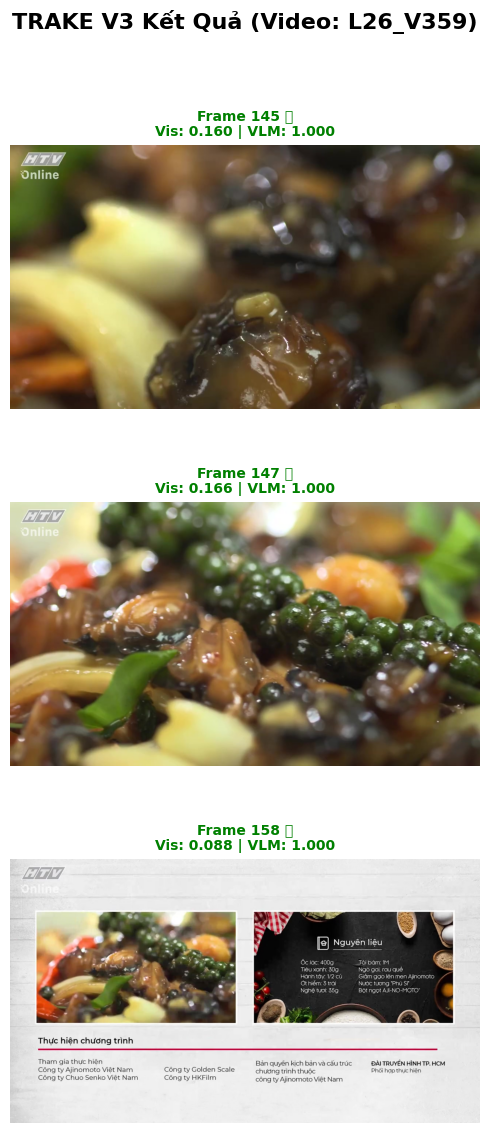

In [14]:
# CELL 13 - INTERACTIVE QUERY & VISUALIZATION
# ================================================================

import time
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ================================================================
# 1. HÀM TRỰC QUAN HÓA 
# ================================================================

def visualize_results(search_output, max_videos=3, frames_per_event=3):
    video_results = search_output.get("results", [])

    if not video_results:
        print("Không tìm thấy video nào.")
        return

    # Chỉ lấy top max_videos
    video_results = video_results[:max_videos]

    for video_rank, video_result in enumerate(video_results, start=1):
        video_id = video_result.get("video_id", "UNKNOWN")
        video_score = video_result.get("score", 0.0)
        events = video_result.get("events", [])

        print()
        print("=" * 100)
        print(f"VIDEO RANK {video_rank}: {video_id} | Final Score: {video_score:.4f}")
        print("=" * 100)

        event_frames_map = {}
        for ev in events:
            if hasattr(ev, "__dict__"):
                ev = vars(ev)
                
            e_id = ev.get("event_id")
            if e_id not in event_frames_map:
                event_frames_map[e_id] = []
            event_frames_map[e_id].append(ev)

        # Sắp xếp các event theo thứ tự (0, 1, 2...)
        sorted_event_ids = sorted(event_frames_map.keys())
        n_events = len(sorted_event_ids)

        if n_events == 0:
            print(f"Video {video_id}: Không có frame nào được ghi nhận.")
            continue

        # Thiết lập bảng vẽ
        fig, axes = plt.subplots(
            n_events,
            frames_per_event,
            figsize=(5 * frames_per_event, 4 * n_events)
        )

        # Chuẩn hóa axes về 2D array
        axes = np.asarray(axes, dtype=object)
        if axes.ndim == 0: axes = axes.reshape(1, 1)
        elif axes.ndim == 1:
            if n_events == 1: axes = axes.reshape(1, -1)
            else: axes = axes.reshape(-1, 1)

        # Xóa các trục trống trước
        for row in axes:
            for ax in np.atleast_1d(row):
                ax.axis("off")

        # Vẽ từng event
        for row_idx, e_id in enumerate(sorted_event_ids):
            candidates = event_frames_map[e_id][:frames_per_event]

            # Label cột dọc cho event
            axes[row_idx, 0].set_ylabel(
                f"EVENT {e_id}", fontsize=12, fontweight='bold', rotation=90, labelpad=15
            )

            for col_idx, frame_data in enumerate(candidates):
                ax = axes[row_idx, col_idx]
                
                image_path = frame_data.get("keyframe_path")
                frame_idx = frame_data.get("frame_idx", "?")
                vis_score = frame_data.get("visual_score", 0.0)
                vlm_score = frame_data.get("semantic_score", 0.0)
                verified = frame_data.get("verified", False)

                if not image_path:
                    ax.set_title("No Path", fontsize=10)
                    continue

                try:
                    image = Image.open(image_path)
                    ax.imshow(image)
                    
                    status_icon = "✅" if verified else "❌"
                    color = "green" if verified else "red"
                    
                    title = (
                        f"Frame {frame_idx} {status_icon}\n"
                        f"Vis: {vis_score:.3f} | VLM: {vlm_score:.3f}"
                    )
                    ax.set_title(title, fontsize=10, color=color, fontweight='bold')
                except Exception as e:
                    ax.set_title(f"Lỗi tải ảnh:\n{e}", fontsize=9, color="red")

        fig.suptitle(f"TRAKE V3 Kết Quả (Video: {video_id})", fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


# ================================================================
# ================================================================
USER_QUERY = [
"An upclose of the first seafood",
"An upclose of the second seafood",
"colorful ingredients"

]
print("=" * 90)
print("ĐANG TÌM KIẾM CHO QUERY:")
for i, q in enumerate(USER_QUERY):
    print(f"   Event {i}: {q}")
print("=" * 90)

# Bắt đầu bấm giờ
start_time = time.time()

# Gọi hàm search
search_output = trake.search(USER_QUERY)

# Kết thúc bấm giờ
elapsed_time = time.time() - start_time
results_count = len(search_output.get("results", []))

print(f"⏱️ Hoàn thành tìm kiếm trong {elapsed_time:.2f} giây.")
print(f"🎯 Tìm thấy {results_count} video.")
print("=" * 90)

# ================================================================
# 3. HIỂN THỊ KẾT QUẢ
# ================================================================
if results_count > 0:
    visualize_results(
        search_output,
        max_videos=5,
        frames_per_event=1  # Vì DANTE chỉ chọn 1 frame tối ưu cho mỗi event, đặt là 1 cho gọn
    )
else:
    print("DANTE không khớp được trình tự thời gian cho bất kỳ video nào.")